In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('sentiment_data.csv', sep=',', encoding='utf-8')

In [3]:
df.head()

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


In [4]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

In [5]:
df.head()

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2


In [6]:
df.isna().sum()

Comment      217
Sentiment      0
dtype: int64

In [7]:
df[df['Comment'].isna()]

,Comment,Sentiment
1014,NaN,1
4732,NaN,1
7414,NaN,2
7431,NaN,1
7496,NaN,1
...,...,...
223441,NaN,1
228310,NaN,2
233352,NaN,1
235494,NaN,1


In [8]:
df.shape

(241145, 2)

In [9]:
df.describe()

,Sentiment
count,241145.000000
mean,1.198822
std,0.785110
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,2.000000


In [10]:
df.dropna(inplace=True)

In [11]:
df.shape

(240928, 2)

In [12]:
df.isna().sum()

Comment      0
Sentiment    0
dtype: int64

In [13]:
# !pip install nltk

In [14]:
df['Comment'] = df['Comment'].apply(lambda x: x.lower())

In [15]:
df['Comment'].head()

0    lets forget apple pay required brand new iphon...
1    nz retailers don’t even contactless credit car...
2    forever acknowledge channel help lessons ideas...
3    whenever go place doesn’t take apple pay doesn...
4    apple pay convenient secure easy use used kore...
Name: Comment, dtype: str

In [16]:
import re

has_html_tag = df['Comment'].str.contains(r'<.*?>', regex=True)
print(f"Number of comments with HTML tags: {has_html_tag.sum()}")

Number of comments with HTML tags: 0


In [17]:

has_url = df['Comment'].str.contains(r'https?://[^\s]+', regex=True)
print(f"Number of comments with URLs: {has_url.sum()}")

Number of comments with URLs: 0


In [18]:
import string

has_punctuation = df['Comment'].str.contains(f"[{re.escape(string.punctuation)}]")
print(f"Number of comments with punctuation: {has_punctuation.sum()}")

Number of comments with punctuation: 0


In [19]:
chat_words = {
    "afaik": "as far as i know", "afk": "away from keyboard",
    "asap": "as soon as possible", "atm": "at the moment",
    "b4": "before", "bc": "because", "bday": "birthday",
    "brb": "be right back", "btw": "by the way", "bff": "best friends forever",
    "cya": "see you", "cu": "see you", "diy": "do it yourself",
    "dm": "direct message", "eta": "estimated time of arrival",
    "fomo": "fear of missing out", "ftw": "for the win",
    "fyi": "for your information", "gg": "good game",
    "gtg": "got to go", "g2g": "got to go", "gr8": "great",
    "hbd": "happy birthday", "hmu": "hit me up",
    "idc": "i do not care", "idk": "i do not know",
    "ikr": "i know right", "ily": "i love you",
    "imo": "in my opinion", "imho": "in my humble opinion",
    "irl": "in real life", "jk": "just kidding",
    "lmk": "let me know", "lol": "laughing out loud",
    "luv": "love", "l8r": "later", "msg": "message",
    "nvm": "never mind", "np": "no problem",
    "omg": "oh my god", "omw": "on my way",
    "ppl": "people", "pls": "please", "plz": "please",
    "rn": "right now", "rofl": "rolling on the floor laughing",
    "smh": "shaking my head", "tbh": "to be honest",
    "thx": "thanks", "ty": "thank you", "tysm": "thank you so much",
    "ttyl": "talk to you later", "tmi": "too much information",
    "u": "you", "ur": "your", "r": "are",
    "w8": "wait", "wyd": "what are you doing",
    "wbu": "what about you", "wth": "what the hell",
    "wtf": "what the fuck", "yolo": "you only live once",
    "2day": "today", "2moro": "tomorrow", "2nite": "tonight",
    "4u": "for you", "b/c": "because", "cuz": "because",
    "gonna": "going to", "wanna": "want to", "gotta": "got to",
    "kinda": "kind of", "sorta": "sort of", "lemme": "let me",
    "gimme": "give me", "dunno": "do not know",
    "aight": "alright", "k": "okay", "kk": "okay",
    "np": "no problem", "nm": "not much", "wassup": "what is up",
    "sup": "what is up", "howdy": "hello",
    "xoxo": "hugs and kisses", "yw": "you are welcome",
    "bday": "birthday", "congrats": "congratulations",
    "def": "definitely", "obv": "obviously", "obvi": "obviously",
    "prob": "probably", "probs": "probably", "totes": "totally",
    "srsly": "seriously", "rly": "really", "vry": "very",
    "abt": "about", "acct": "account", "addy": "address",
    "app": "application", "bbl": "be back later",
    "bday": "birthday", "convo": "conversation",
    "fam": "family", "fav": "favorite", "fave": "favorite",
    "grats": "congratulations", "hru": "how are you",
    "hw": "homework", "ic": "i see", "iirc": "if i recall correctly",
    "jic": "just in case", "jsyk": "just so you know",
    "msg": "message", "nbd": "no big deal", "nsfw": "not safe for work",
    "ofc": "of course", "outta": "out of", "peeps": "people",
    "pic": "picture", "pics": "pictures", "pov": "point of view",
    "qt": "cutie", "sec": "second", "sis": "sister", "bro": "brother",
    "tho": "though", "thru": "through", "til": "until",
    "w/": "with", "w/o": "without", "y": "why",
    "ya": "you", "yea": "yeah", "yep": "yes", "nope": "no",
    "cmon": "come on", "dont": "do not", "cant": "cannot",
    "wont": "will not", "im": "i am", "ive": "i have",
    "id": "i would", "ill": "i will"
}

pattern = r'\b(' + '|'.join(re.escape(k) for k in chat_words.keys()) + r')\b'
has_chat_words = df['Comment'].str.contains(pattern, regex=True)
print(f"Number of comments with chat words: {has_chat_words.sum()}")

/var/folders/hg/ybvpz2sd5pxg82v04p1v28w00000gn/T/ipykernel_3921/1325410124.py:62: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_chat_words = df['Comment'].str.contains(pattern, regex=True)


Number of comments with chat words: 43899


In [20]:
pattern = r'\b(' + '|'.join(re.escape(k) for k in chat_words.keys()) + r')\b'
matched_chat_words = df['Comment'].str.findall(pattern, flags=re.IGNORECASE)
matched_chat_words.head()

0    []
1    []
2    []
3    []
4    []
Name: Comment, dtype: object

In [21]:
mask = df['Comment'].str.contains('ive', case=False, na=False)
df[mask]

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
9,cambodia universal qr code system scan send mo...,1
11,lab exciting thing ive seen reallly going shak...,2
13,used time linus smartest guy room video clearl...,2
25,dan man saving day riley needs give theme like...,2
...,...,...
241130,people say modi looking defensive days,1
241134,objective cover everything akhlaq ramalingam q...,2
241137,engine growth modi unveils indias first electr...,2
241138,modi promised lok sabha elections best orop gi...,2


In [22]:
matched_chat_words = matched_chat_words[matched_chat_words.str.len() > 0]

In [23]:
matched_chat_words

11          [ive]
12           [im]
19        [gonna]
29           [id]
40         [dont]
           ...   
241113     [wont]
241122     [dont]
241133     [dont]
241134     [dont]
241135     [wont]
Name: Comment, Length: 43899, dtype: object

In [24]:
import re

pattern = re.compile(
    r'\b(' + '|'.join(re.escape(k) for k in chat_words.keys()) + r')\b',
    flags=re.IGNORECASE
)

def chat_word_conversion(txt):
    return pattern.sub(lambda m: chat_words[m.group(0).lower()], txt)


In [25]:
df['cleaned_comment'] = df['Comment'].apply(chat_word_conversion)

In [26]:
df.head()

,Comment,Sentiment,cleaned_comment
0,lets forget apple pay required brand new iphon...,1,lets forget apple pay required brand new iphon...
1,nz retailers don’t even contactless credit car...,0,nz retailers don’t even contactless credit car...
2,forever acknowledge channel help lessons ideas...,2,forever acknowledge channel help lessons ideas...
3,whenever go place doesn’t take apple pay doesn...,0,whenever go place doesn’t take apple pay doesn...
4,apple pay convenient secure easy use used kore...,2,apple pay convenient secure easy use used kore...


In [27]:
pattern = r'\b(' + '|'.join(re.escape(k) for k in chat_words.keys()) + r')\b'
has_chat_words = df['cleaned_comment'].str.contains(pattern, regex=True)
print(f"Number of comments with chat words: {has_chat_words.sum()}")

/var/folders/hg/ybvpz2sd5pxg82v04p1v28w00000gn/T/ipykernel_3921/337416178.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_chat_words = df['cleaned_comment'].str.contains(pattern, regex=True)


Number of comments with chat words: 0


In [28]:
pattern = r'\b(' + '|'.join(re.escape(k) for k in chat_words.keys()) + r')\b'
matched_chat_words = df['cleaned_comment'].str.findall(pattern, flags=re.IGNORECASE)
matched_chat_words.head()

0    []
1    []
2    []
3    []
4    []
Name: cleaned_comment, dtype: object

In [29]:
matched_chat_words = matched_chat_words[matched_chat_words.str.len() > 0]

In [30]:
matched_chat_words

Series([], Name: cleaned_comment, dtype: object)

In [31]:
df.head()

,Comment,Sentiment,cleaned_comment
0,lets forget apple pay required brand new iphon...,1,lets forget apple pay required brand new iphon...
1,nz retailers don’t even contactless credit car...,0,nz retailers don’t even contactless credit car...
2,forever acknowledge channel help lessons ideas...,2,forever acknowledge channel help lessons ideas...
3,whenever go place doesn’t take apple pay doesn...,0,whenever go place doesn’t take apple pay doesn...
4,apple pay convenient secure easy use used kore...,2,apple pay convenient secure easy use used kore...


In [32]:
df[df['cleaned_comment'].str.contains(r'\bomg\b', case=False, regex=True, na=False)]

,Comment,Sentiment,cleaned_comment


In [33]:
df['Comment'] = df['cleaned_comment']
df = df.drop(columns=['cleaned_comment'])

In [34]:
df.head()

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2


In [35]:
# !pip install pyspellchecker

In [36]:
from spellchecker import SpellChecker

spell = SpellChecker()

def correct_spelling(text):
    words = text.split()
    corrected_words = [spell.correction(word) for word in words]
    return ' '.join(corrected_words)

In [37]:
def check_spelling(text):
    words = text.split()
    corrected_words = [{ 'word': word, 'corrected': spell.correction(word) } for word in words]

In [38]:
# result = df['Comment'].apply(check_spelling)

In [39]:
# result.head()

In [40]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

[nltk_data] Downloading package stopwords to /Users/nayan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [41]:
df['Comment'] = df['Comment'].apply(remove_stopwords)

In [42]:
# !pip install emoji

In [43]:
import emoji

def has_emoji(text):
    return bool(emoji.emoji_list(text))

In [44]:
df['has_emoji'] = df['Comment'].apply(has_emoji)
print(f"Number of comments with emojis: {df['has_emoji'].sum()}")

Number of comments with emojis: 518


In [45]:
df[df['has_emoji'] == True]

,Comment,Sentiment,has_emoji
47118,💩👎💩👎💩👎💩 👻☠️ impossible delete list sub lists t...,0,True
47434,reminder feature working 🥱,0,True
47480,regular user appthis application needs update ...,1,True
47576,literally blessed know todoist♥️,2,True
47587,application good past anymore stopped sync man...,0,True
...,...,...,...
237048,modi interacted citizens new delhi everyone to...,2,True
237752,might get dã©jã watching interview reminisce i...,2,True
238942,ravi listening modi â speech today must tell...,2,True
239041,à¤¿à¥ à¥à¥à¤ à¤¼à¥ à¥ à¥à¤°à¤à¤®à¤¾à¤¨...,1,True


In [46]:
def convert_emojis(text):
    return emoji.demojize(text, delimiters=("", ""))

In [47]:
df['Comment'] = df['Comment'].apply(convert_emojis)

In [48]:
df[df['has_emoji'] == True]

,Comment,Sentiment,has_emoji
47118,pile_of_poothumbs_downpile_of_poothumbs_downpi...,0,True
47434,reminder feature working yawning_face,0,True
47480,regular user appthis application needs update ...,1,True
47576,literally blessed know todoistheart_suit,2,True
47587,application good past anymore stopped sync man...,0,True
...,...,...,...
237048,modi interacted citizens new delhi everyone to...,2,True
237752,might get dãcopyrightjã watching interview rem...,2,True
238942,ravi listening modi â speech today must tell...,2,True
239041,à¤¿à¥ à¥à¥à¤ à¤¼à¥ à¥ à¥à¤°à¤à¤registe...,1,True


In [49]:
def has_non_ascii(text):
    return any(ord(char) > 127 for char in text)

In [50]:
df['has_non_ascii'] = df['Comment'].apply(has_non_ascii)
print(f"Rows with non-ASCII characters: {df['has_non_ascii'].sum()}")

Rows with non-ASCII characters: 24480


In [51]:
df[df['has_non_ascii'] == True].sample(5)

,Comment,Sentiment,has_emoji,has_non_ascii
85307,sanghi economist doesnâ convince modi put hi...,0,False,True
202806,ktr ground reality change past estimate ppll t...,2,False,True
157324,pmowish happy world theatre day rahul gandhi m...,2,False,True
212514,hear bjp leaders talk country safe modiâ han...,2,False,True
214810,murky arms deal haunts modiindiaâ prime mini...,1,False,True


In [52]:
with pd.option_context('display.max_colwidth', None):
    print(df[df['has_non_ascii'] == True].sample(5))

                                                                                                                                                        Comment  \
238232                                                                modi contesting varanasi polarizationraga contesting wayanad secularismà³à³à³à³à³à²¾   
112891  akshay sir full speech scaryyou endorsing hitlerâ ideathat modi anti india pak devoid values rights india colourful due constitution democracy let â   
180006       bhakt buys analogies years letâ clear two types voters modi modi people modi wouldnâ change mind whatever priyanka need consolidate votes modi   
209380                                        india everyone calls statesman doubt prime minister modi blasted indian public øªø¹ø±ûù ø¯ø´ù ù úcopyrightø±û   
107194                                                        whether feeds bullets biryani terrorists issue separate debate ajay sing bishtâ head full filth   

        Sentiment  ha

In [53]:
def fix_mojibake(text):
    if not isinstance(text, str):
        return text
    try:
        return text.encode('latin1').decode('utf-8')
    except (UnicodeDecodeError, UnicodeEncodeError) as e:
        print(f"Failed on: {text[:50]}... | Error: {e}")
        return text

In [54]:
sample = "à¤¿à¥ some text à¥ here"
print(fix_mojibake(sample))

Failed on: à¤¿à¥ some text à¥ here... | Error: 'utf-8' codec can't decode bytes in position 3-4: invalid continuation byte
à¤¿à¥ some text à¥ here


In [55]:
df['Comment'] = df['Comment'].apply(fix_mojibake)

Failed on: nz retailers don’t even contactless credit card ma... | Error: 'latin-1' codec can't encode character '\u2019' in position 16: ordinal not in range(256)
Failed on: whenever go place doesn’t take apple pay doesn’t h... | Error: 'latin-1' codec can't encode character '\u2019' in position 23: ordinal not in range(256)
Failed on: we’ve hounding bank adopt apple pay understand don... | Error: 'latin-1' codec can't encode character '\u2019' in position 2: ordinal not in range(256)
Failed on: got apple pay south africa it’s widely accepted... | Error: 'latin-1' codec can't encode character '\u2019' in position 29: ordinal not in range(256)
Failed on: linus turn key lights bounce walls you’ll get much... | Error: 'latin-1' codec can't encode character '\u2019' in position 38: ordinal not in range(256)
Failed on: liquid nitrogen ഇതുവരെ തീർന്നില്ലേ മച്ചാനെ... | Error: 'latin-1' codec can't encode characters in position 16-21: ordinal not in range(256)
Failed on: കേരളത്തിൽ ആദ്യമായി പെട

In [56]:
df['has_non_ascii'] = df['Comment'].apply(has_non_ascii)
print(f"Rows with non-ASCII characters: {df['has_non_ascii'].sum()}")

Rows with non-ASCII characters: 24480


In [57]:
df[df['has_non_ascii'] == True].sample(5)

,Comment,Sentiment,has_emoji,has_non_ascii
158453,last checked program wasn’ called modi antarik...,2,False,True
198353,modi’ speech didn’ violate model code conduct,1,False,True
12777,chris “you follow footsteps man”,1,False,True
188352,former isro chief called upa govt disaster rec...,2,False,True
126766,’ proud day indian citizen country missile sho...,2,False,True


In [58]:
import unicodedata

def has_any_punct(text):
    return any(unicodedata.category(char).startswith('P') for char in text)

df['has_punct'] = df['Comment'].apply(has_any_punct)
print(df['has_punct'].sum())

18483


In [59]:
def remove_all_punct(text):
    return ''.join(char for char in text if not unicodedata.category(char).startswith('P'))

In [60]:
df['Comment'] = df['Comment'].apply(remove_all_punct)

In [61]:
df.sample(5)

,Comment,Sentiment,has_emoji,has_non_ascii,has_punct
3191,economics increasing supply money increases in...,0,False,False,False
149529,modi economist modi say demo successful took s...,2,False,False,False
641,watching wish best everything wish best everyt...,2,False,False,False
2491,im impressed max dude super smart running like...,2,False,True,True
110155,think narendra modi honble prime minister indi...,2,False,False,False


In [62]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /Users/nayan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [63]:
from nltk.tokenize import word_tokenize

df['tokenized_comment'] = df['Comment'].apply(word_tokenize)

In [64]:
df.head()

,Comment,Sentiment,has_emoji,has_non_ascii,has_punct,tokenized_comment
0,lets forget apple pay required brand new iphon...,1,False,False,False,"[lets, forget, apple, pay, required, brand, ne..."
1,nz retailers dont even contactless credit card...,0,False,True,True,"[nz, retailers, dont, even, contactless, credi..."
2,forever acknowledge channel help lessons ideas...,2,False,False,False,"[forever, acknowledge, channel, help, lessons,..."
3,whenever go place doesnt take apple pay doesnt...,0,False,True,True,"[whenever, go, place, doesnt, take, apple, pay..."
4,apple pay convenient secure easy use used kore...,2,False,False,False,"[apple, pay, convenient, secure, easy, use, us..."


In [65]:
# !pip install spacy

In [66]:
# !python -m spacy download en_core_web_sm

In [67]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [68]:
def lemmatize_token_spacy(tokens):
    text = ' '.join(tokens)
    doc = nlp(text)
    return [token.lemma_ for token in doc]

In [69]:
sample = "the cats were running quickly through the studies"
doc = nlp(sample)
for token in doc:
    print(token.text, "→", token.lemma_, f"({token.pos_})")

the → the (DET)
cats → cat (NOUN)
were → be (AUX)
running → run (VERB)
quickly → quickly (ADV)
through → through (ADP)
the → the (DET)
studies → study (NOUN)


In [70]:
# df['tokens'] = df['tokens'].apply(lemmatize_token_spacy)
# We won't be using this as we have too many rows and it takes a long time to process. Instead: 

In [71]:
def lematize_tokens_batch_spacy(tokens_list):
    texts = [' '.join(tokens) for tokens in tokens_list]
    docs = nlp.pipe(texts)
    return [[token.lemma_ for token in doc] for doc in docs]

In [72]:
df['tokenized_comment'] = lematize_tokens_batch_spacy(df['tokenized_comment'].tolist())

In [73]:
df.head()

,Comment,Sentiment,has_emoji,has_non_ascii,has_punct,tokenized_comment
0,lets forget apple pay required brand new iphon...,1,False,False,False,"[let, forget, apple, pay, require, brand, new,..."
1,nz retailers dont even contactless credit card...,0,False,True,True,"[nz, retailer, do, not, even, contactless, cre..."
2,forever acknowledge channel help lessons ideas...,2,False,False,False,"[forever, acknowledge, channel, help, lesson, ..."
3,whenever go place doesnt take apple pay doesnt...,0,False,True,True,"[whenever, go, place, do, not, take, apple, pa..."
4,apple pay convenient secure easy use used kore...,2,False,False,False,"[apple, pay, convenient, secure, easy, use, us..."


In [74]:
empty_rows = df[df['tokenized_comment'].apply(len) == 0]
print(f"Empty token rows: {len(empty_rows)}")

Empty token rows: 26


In [75]:
df = df[df['tokenized_comment'].apply(len) > 0]

In [76]:
empty_rows = df[df['tokenized_comment'].apply(len) == 0]
print(f"Empty token rows: {len(empty_rows)}")

Empty token rows: 0


In [77]:
df.head()

,Comment,Sentiment,has_emoji,has_non_ascii,has_punct,tokenized_comment
0,lets forget apple pay required brand new iphon...,1,False,False,False,"[let, forget, apple, pay, require, brand, new,..."
1,nz retailers dont even contactless credit card...,0,False,True,True,"[nz, retailer, do, not, even, contactless, cre..."
2,forever acknowledge channel help lessons ideas...,2,False,False,False,"[forever, acknowledge, channel, help, lesson, ..."
3,whenever go place doesnt take apple pay doesnt...,0,False,True,True,"[whenever, go, place, do, not, take, apple, pa..."
4,apple pay convenient secure easy use used kore...,2,False,False,False,"[apple, pay, convenient, secure, easy, use, us..."


In [78]:
df = df[['tokenized_comment', 'Sentiment']]

In [79]:
df.head()

,tokenized_comment,Sentiment
0,"[let, forget, apple, pay, require, brand, new,...",1
1,"[nz, retailer, do, not, even, contactless, cre...",0
2,"[forever, acknowledge, channel, help, lesson, ...",2
3,"[whenever, go, place, do, not, take, apple, pa...",0
4,"[apple, pay, convenient, secure, easy, use, us...",2


In [80]:
df.head()

,tokenized_comment,Sentiment
0,"[let, forget, apple, pay, require, brand, new,...",1
1,"[nz, retailer, do, not, even, contactless, cre...",0
2,"[forever, acknowledge, channel, help, lesson, ...",2
3,"[whenever, go, place, do, not, take, apple, pa...",0
4,"[apple, pay, convenient, secure, easy, use, us...",2


In [81]:
df['text_for_vectorization'] = df['tokenized_comment'].apply(lambda tokens: ' '.join(tokens))

In [82]:
df.head()

,tokenized_comment,Sentiment,text_for_vectorization
0,"[let, forget, apple, pay, require, brand, new,...",1,let forget apple pay require brand new iphone ...
1,"[nz, retailer, do, not, even, contactless, cre...",0,nz retailer do not even contactless credit car...
2,"[forever, acknowledge, channel, help, lesson, ...",2,forever acknowledge channel help lesson idea e...
3,"[whenever, go, place, do, not, take, apple, pa...",0,whenever go place do not take apple pay do not...
4,"[apple, pay, convenient, secure, easy, use, us...",2,apple pay convenient secure easy use use korea...


In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer()

vectorizer = TfidfVectorizer(
    max_features=5000,   # cap vocabulary size, keeps only top 5000 most frequent/informative words
    min_df=5,            # ignore words appearing in fewer than 5 documents (likely noise/typos)
    max_df=0.8           # ignore words appearing in more than 80% of documents (too common to be useful)
)

In [84]:
X = vectorizer.fit_transform(df['text_for_vectorization'])
print(X.shape)

(240902, 5000)


In [85]:
X[0].toarray().flatten()

array([0., 0., 0., ..., 0., 0., 0.], shape=(5000,))

In [86]:
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")
print(X[0].toarray())

feature_names = vectorizer.get_feature_names_out()
row = X[0].toarray().flatten()
top_indices = row.argsort()[-5:][::-1]
for idx in top_indices:
    print(feature_names[idx], row[idx])

Vocabulary size: 5000
[[0. 0. 0. ... 0. 0. 0.]]
iphone 0.529816452840272
apple 0.34609232091069125
technology 0.3195945070390283
use 0.3150039654916359
significant 0.1926373115100565


In [87]:
y = df['Sentiment']

In [88]:
y

0         1
1         0
2         2
3         0
4         2
         ..
241140    0
241141    0
241142    1
241143    1
241144    2
Name: Sentiment, Length: 240902, dtype: int64

In [89]:
y.unique()

array([1, 0, 2])

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 192721 samples
Test set size: 48181 samples


In [91]:
print(df['Sentiment'].value_counts())
print(df['Sentiment'].value_counts(normalize=True))

Sentiment
2    103045
1     82752
0     55105
Name: count, dtype: int64
Sentiment
2    0.427747
1    0.343509
0    0.228744
Name: proportion, dtype: float64


In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [93]:
y_pred = model.predict(X_test)

In [94]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.7671696311824163
              precision    recall  f1-score   support

           0       0.76      0.63      0.69     11021
           1       0.73      0.80      0.76     16551
           2       0.81      0.81      0.81     20609

    accuracy                           0.77     48181
   macro avg       0.76      0.75      0.75     48181
weighted avg       0.77      0.77      0.77     48181



In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

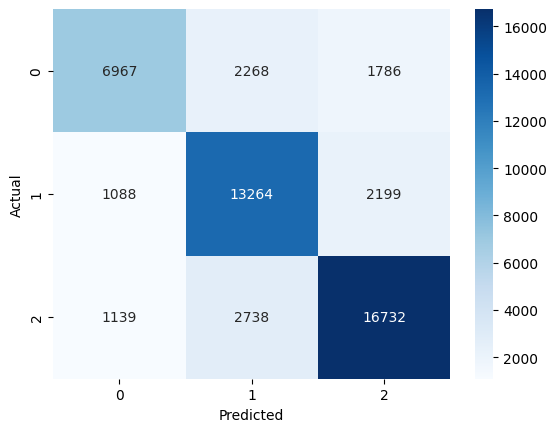

In [96]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Hyper-parameter Tuned Model

In [97]:
from scipy.stats import uniform, loguniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score

In [ ]:
# param_dist = {
#     "C": loguniform(1e-3, 1e2),
#     "l1_ratio": uniform(0, 1),
#     "solver": ["saga"],
#     "class_weight": [None, "balanced"],
# }

param_dist = {
    "C": [0.01, 0.1, 1, 10, 100],
    "l1_ratio": [1, 0.5, 0.1, 0.01],
    "solver": ["saga"],
    "class_weight": [None, "balanced"],
}

tuned_model = LogisticRegression(max_iter=1000, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    tuned_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='accuracy',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best score:", random_search.best_score_)
best_model = random_search.best_estimator_

/Users/nayan/ml/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
y_pred_hyperparam = best_model.predict(X_test)

In [ ]:
print(f"Accuracy after hyperparameter tuning: {accuracy_score(y_test, y_pred_hyperparam)}")
print('Classification report after hyperparameter tuning:')
print(classification_report(y_test, y_pred_hyperparam))